# Lightweight Recurrence Plot CNN — Multi-Class (5-way) CAN Intrusion Detection

Extends the binary DoS-only pipeline (`final.ipynb`) to the five-class scope
originally specified in the Formal Project Proposal: **Normal, DoS, Fuzzy,
Gear-spoofing, RPM-spoofing**.

Requires four HCRL Car-Hacking CSV files in the same directory as `DoS_dataset.csv`:
`Fuzzy_dataset.csv`, `gear_dataset.csv`, `RPM_dataset.csv` (all downloadable from
the same source cited in Appendix A: https://ocslab.hksecurity.net/Datasets/car-hacking-dataset).

This notebook also fixes the Section 5.4 finding (train/inference arbitration-ID
preprocessing mismatch) by persisting the factorisation mapping learned during
training inside the checkpoint and re-using it — rather than re-deriving IDs —
at inference time.


In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\myenv\Scripts\python.exe -m pip install --upgrade pip' command.


In [3]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for research reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using compute device: {device}")


[INFO] Using compute device: cpu


## STEP 1: Multi-class data loading & leakage-safe windowing

Each of the four source files contributes **both** Normal windows (its
'R'-flagged frames) and one specific attack class (its 'T'-flagged frames).
Arbitration IDs are factorised into a single **global, persisted**
categorical index shared across all four files, so the same CAN_ID string
always maps to the same integer — this mapping is saved into the checkpoint
and re-applied at inference time (fixes the Section 5.4
preprocessing-consistency issue found in the binary pipeline).

**Leakage fix (new):** with `stride=16` on `window_size=128`, adjacent
sliding windows overlap by up to 87.5% of their frames. Every window is now
tagged with a `group_id` identifying the non-overlapping 128-frame block it
came from (per class/file). STEP 2 uses `GroupShuffleSplit` on this
`group_id` instead of a plain random `train_test_split`, guaranteeing no
test window shares raw frames with any training window.

In [4]:
CLASS_NAMES = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
NUM_CLASSES = len(CLASS_NAMES)

ATTACK_FILES = {
    1: ("DoS",   r"C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\DoS_dataset new.csv"),
    2: ("Fuzzy", r"C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\Fuzzy_dataset.csv"),
    3: ("Gear",  r"C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\gear_dataset.csv"),
    4: ("RPM",   r"C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\RPM_dataset.csv"),
}

CSV_COLUMNS = ['Timestamp', 'CAN_ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']


def load_and_preprocess_multiclass(attack_files, window_size=128, stride=16,
                                    max_samples_per_class=4000,
                                    attack_frame_fraction_threshold=0.08,
                                    normal_frac_ceiling=0.0):
    """
    Loads all four HCRL Car-Hacking CSV files, factorises CAN_ID into a single
    GLOBAL categorical index shared across files (persisted for later reuse
    at inference time), and extracts overlapping sliding-window sequences.

    IMPORTANT — threshold tuning: DoS and Fuzzy attacks inject at a high
    enough rate that a majority of frames in an attack-window ARE the attack.
    Gear/RPM spoofing inject a specific ID only once per ~1ms alongside
    substantial normal background traffic, so their attack frames are a
    MINORITY of any window even during a genuine attack burst. A single
    "majority vote" threshold (0.5) that worked for DoS/Fuzzy silently
    produced ZERO usable windows for Gear/RPM in an earlier run. This version:

    1. Uses a much lower default threshold (0.08, i.e. >= ~10 attack frames
       out of 128) that is reachable for low-rate targeted attacks.
    2. Prints the actual attack-frame-density distribution observed per file
       BEFORE balancing, so the threshold can be tuned from real numbers
       instead of guessed blind. If any class still comes back empty, raise
       or lower `attack_frame_fraction_threshold` and re-run this cell only.
    3. Still requires attack_frac <= normal_frac_ceiling (default 0.0, i.e.
       truly zero attack frames) for a window to count as Normal, keeping
       Normal-class labels clean.

    Normal-class diversity: normal windows are capped PER SOURCE FILE so the
    final Normal class is an even mix of all four recording sessions.

    LEAKAGE-SAFE GROUP ID (NEW): stride=16 on window_size=128 means adjacent
    windows overlap by up to 87.5% of their frames. A random train/test split
    on the flat window array can therefore put near-duplicate windows on both
    sides of the split, inflating test accuracy without the model learning
    anything genuinely generalisable. To fix this, every window is now tagged
    with a `group_id` string encoding (class, source file, non-overlapping
    block index = start_idx // window_size). Windows that fall in the same
    block are guaranteed to overlap and are always kept together on the same
    side of the split. This group_id is consumed downstream by
    GroupShuffleSplit (STEP 2) instead of a plain random train_test_split.
    """
    import os as _os
    global_can_id_map = {}
    next_id = 0

    # Now store (start_idx, seq) tuples so a leakage-safe group_id can be
    # derived later, instead of storing only the raw sequences.
    attack_seqs = {i: [] for i in range(1, NUM_CLASSES)}
    normal_seqs_by_file = {}
    frac_diagnostics = {}   # per-file: distribution of nonzero attack_frac values

    present_files = {k: v for k, v in attack_files.items() if _os.path.exists(v[1])}
    for attack_label, (name, path) in attack_files.items():
        if attack_label not in present_files:
            print(f"[WARN] Missing file for class '{name}': {path} — skipping.")
            continue

        print(f"[INFO] Reading {name} traffic from: {path}")
        df = pd.read_csv(path, names=CSV_COLUMNS, on_bad_lines='skip', low_memory=False)
        df['CAN_ID'] = df['CAN_ID'].astype(str).str.strip()

        cat_ids = np.empty(len(df), dtype=np.int64)
        can_id_values = df['CAN_ID'].values
        for i, cid in enumerate(can_id_values):
            idx = global_can_id_map.get(cid)
            if idx is None:
                idx = next_id
                global_can_id_map[cid] = idx
                next_id += 1
            cat_ids[i] = idx

        lbl_vals = (df['Flag'].astype(str).str.strip().str.upper() != 'R').astype(int).values

        file_normal_seqs = []
        nonzero_fracs = []
        for i in range(0, len(cat_ids) - window_size, stride):
            win_seq = cat_ids[i:i + window_size]
            attack_frac = np.mean(lbl_vals[i:i + window_size] == 1)

            if attack_frac <= normal_frac_ceiling:
                file_normal_seqs.append((i, win_seq))
            else:
                nonzero_fracs.append(attack_frac)
                if attack_frac >= attack_frame_fraction_threshold:
                    attack_seqs[attack_label].append((i, win_seq))
                # else: below threshold but nonzero -> dropped as ambiguous

        normal_seqs_by_file[name] = file_normal_seqs
        if nonzero_fracs:
            nz = np.array(nonzero_fracs)
            frac_diagnostics[name] = {
                "windows_with_any_attack_frame": len(nz),
                "min_frac": round(float(nz.min()), 4),
                "median_frac": round(float(np.median(nz)), 4),
                "mean_frac": round(float(nz.mean()), 4),
                "max_frac": round(float(nz.max()), 4),
                "pct_above_threshold": round(float((nz >= attack_frame_fraction_threshold).mean() * 100), 2),
            }
        else:
            frac_diagnostics[name] = {"windows_with_any_attack_frame": 0}

    print("\n[DIAGNOSTIC] Attack-frame-density distribution per file "
          f"(threshold currently = {attack_frame_fraction_threshold}):")
    for name, stats in frac_diagnostics.items():
        print(f"  {name}: {stats}")
    print("  If a class's 'pct_above_threshold' is 0%, LOWER attack_frame_fraction_threshold "
          "below its 'max_frac' and re-run this cell.\n")

    class_seqs = {0: []}
    class_seqs.update(attack_seqs)

    counts = {"Normal (raw, per file)": {k: len(v) for k, v in normal_seqs_by_file.items()}}
    counts.update({CLASS_NAMES[c]: len(v) for c, v in attack_seqs.items()})
    print(f"[INFO] Raw window counts (pre-balancing): {counts}")

    available_attack = [c for c in attack_seqs if len(attack_seqs[c]) > 0]
    n_normal_files = len(normal_seqs_by_file) if normal_seqs_by_file else 1

    min_count_attack = min([len(attack_seqs[c]) for c in available_attack], default=0)
    min_count = min(min_count_attack, max_samples_per_class) if available_attack else max_samples_per_class

    per_file_normal_cap = max(1, min_count // max(1, n_normal_files))
    normal_combined = []
    for name, seqs in normal_seqs_by_file.items():
        # tag each Normal window's group_id with its source file so windows
        # from different files never collide into the same group
        normal_combined.extend([(f"Normal::{name}", start, seq) for start, seq in seqs[:per_file_normal_cap]])
    class_seqs[0] = normal_combined

    # For attack classes, tag group_id with class name + file (file is fixed
    # per attack class here, since each attack CSV maps to exactly one class)
    for c in available_attack:
        name = CLASS_NAMES[c]
        class_seqs[c] = [(f"{name}::{name}", start, seq) for start, seq in attack_seqs[c]]

    available = [c for c in class_seqs if len(class_seqs[c]) > 0]

    if len(available) < NUM_CLASSES:
        missing = [CLASS_NAMES[c] for c in range(NUM_CLASSES) if c not in available]
        print(f"[WARN] Missing/empty data for classes: {missing}. "
              f"If unintended, lower attack_frame_fraction_threshold per the diagnostic above.")

    min_count = min(min(len(class_seqs[c]) for c in available), max_samples_per_class)
    print(f"[INFO] Balancing to {min_count} windows per available class "
          f"(Normal drawn from up to {n_normal_files} source files, "
          f"~{per_file_normal_cap} windows/file).")

    X_list, y_list, group_list = [], [], []
    for cls in available:
        chosen = class_seqs[cls][:min_count]
        for tag, start, seq in chosen:
            X_list.append(seq)
            y_list.append(cls)
            # non-overlapping block index: windows sharing a block are
            # guaranteed to overlap in raw frames and must stay together
            block_idx = start // window_size
            group_list.append(f"{tag}#{block_idx}")

    X_raw = np.array(X_list)
    y_raw = np.array(y_list)
    group_raw = np.array(group_list)

    indices = np.arange(len(X_raw))
    np.random.shuffle(indices)
    X_raw = X_raw[indices]
    y_raw = y_raw[indices]
    group_raw = group_raw[indices]

    print(f"[INFO] Final multi-class dataset: {len(X_raw)} windows across "
          f"{len(available)} classes -> {[CLASS_NAMES[c] for c in available]}")
    print(f"[INFO] {len(np.unique(group_raw))} unique leakage-safe groups "
          f"(non-overlapping {window_size}-frame blocks) across all windows.")

    return X_raw, y_raw, group_raw, global_can_id_map, available


X_raw, y_raw, GROUP_RAW, CAN_ID_MAP, PRESENT_CLASSES = load_and_preprocess_multiclass(
    attack_files=ATTACK_FILES,
    window_size=128,
    stride=16,
    max_samples_per_class=4000,
    attack_frame_fraction_threshold=0.08,   # lowered from 0.5 — see diagnostic printout
    normal_frac_ceiling=0.0
)


[INFO] Reading DoS traffic from: C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\DoS_dataset new.csv
[INFO] Reading Fuzzy traffic from: C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\Fuzzy_dataset.csv
[INFO] Reading Gear traffic from: C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\gear_dataset.csv
[INFO] Reading RPM traffic from: C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\RPM_dataset.csv

[DIAGNOSTIC] Attack-frame-density distribution per file (threshold currently = 0.08):
  DoS: {'windows_with_any_attack_frame': 227919, 'min_frac': 0.0078, 'median_frac': 0.0156, 'mean_frac': 0.1697, 'max_frac': 0.7188, 'pct_above_threshold': 30.35}
  Fuzzy: {'windows_with_any_attack_frame': 239256, 'min_frac': 0.0078, 'median_frac': 0.0547, 'mean_frac': 0.1514, 'max_frac': 0.6484, 'pct_above_threshold': 34.24}
  Gear: {'windows_with_any_attack_frame': 277217, 'min_frac': 0.0078, 'median_frac': 0.0156, 'mean_frac': 0.1437, 'max_frac': 0.4766, 'pct_above_threshold'

## STEP 2: Native Categorical Recurrence Plot Generation + Leakage-Safe 3-Way Split

Identical equality-matrix operation to the binary pipeline
(`R[i,j] = 1 if X[i] == X[j]`), applied unchanged since it is class-agnostic.

**Model-selection leakage fix (new):** an earlier version of this notebook used
`test_loader` itself as the "validation" set driving early stopping and best-
checkpoint selection (STEP 4). That meant the epoch/checkpoint kept was chosen
*because* it scored best on the same partition later reported as "held-out test
accuracy" — a genuine model-selection leakage, distinct from the frame-overlap
leakage GroupShuffleSplit already fixes. This is corrected here by carving a
**third, dedicated validation partition out of the training set only**, using
the same group-aware `GroupShuffleSplit` as everywhere else in this notebook.
`test_loader` is now touched exactly once, in STEP 5 evaluation, and never
during training or early stopping.

`[CHECK]` lines print the number of shared groups between every pair of
partitions (train/val, val/test, train/test) so the full 3-way split is
verifiably leakage-safe, not just assumed.


In [5]:
print("[INFO] Generating Native Categorical Recurrence Plots...")

def generate_categorical_rp(X_sequences):
    """
    Transforms 1D categorical CAN ID sequences into 2D Recurrence Plots
    by evaluating exact frame equality (1 if ID_i == ID_j, else 0).
    """
    N, W = X_sequences.shape
    rp_matrices = (X_sequences[:, :, None] == X_sequences[:, None, :]).astype(np.float32)
    return rp_matrices

X_rp = generate_categorical_rp(X_raw)
X_rp = np.expand_dims(X_rp, axis=1)  # (N, 1, W, W)

# LEAKAGE FIX (frame overlap): overlapping sliding windows (stride=16, window=128)
# share up to 87.5% of their frames with their neighbours. Splitting the flattened,
# shuffled window array with a plain random train_test_split lets near-duplicate
# windows land on both sides of the split, inflating test accuracy without genuine
# generalisation. GroupShuffleSplit instead keeps every window sharing a `group_id`
# (same class/file/non-overlapping block, assigned in STEP 1) entirely on one side
# of the split, so no test window can share raw frames with any training window.
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X_rp, y_raw, groups=GROUP_RAW))

X_train, X_test = X_rp[train_idx], X_rp[test_idx]
y_train, y_test = y_raw[train_idx], y_raw[test_idx]
group_train, group_test = GROUP_RAW[train_idx], GROUP_RAW[test_idx]

# LEAKAGE FIX (model selection, new): carve a genuine VALIDATION set out of the
# TRAINING partition only. This is what STEP 4's early stopping / best-checkpoint
# selection uses from now on -- test_loader is no longer touched until STEP 5,
# so "held-out test accuracy" is no longer the same partition the checkpoint was
# chosen to perform well on.
val_gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_idx, val_idx = next(val_gss.split(X_train, y_train, groups=group_train))

X_val, y_val, group_val = X_train[val_idx], y_train[val_idx], group_train[val_idx]
X_train, y_train, group_train = X_train[tr_idx], y_train[tr_idx], group_train[tr_idx]

# Sanity checks: confirm zero group overlap between EVERY pair of partitions
train_test_overlap = set(np.unique(group_train)) & set(np.unique(group_test))
train_val_overlap = set(np.unique(group_train)) & set(np.unique(group_val))
val_test_overlap = set(np.unique(group_val)) & set(np.unique(group_test))
print(f"[CHECK] Groups shared between train and test: {len(train_test_overlap)} (must be 0)")
print(f"[CHECK] Groups shared between train and val:  {len(train_val_overlap)} (must be 0)")
print(f"[CHECK] Groups shared between val and test:   {len(val_test_overlap)} (must be 0)")
print(f"[INFO] Leakage-safe 3-way split -> train: {len(X_train)} windows, "
      f"val: {len(X_val)} windows, test: {len(X_test)} windows")

class CANDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_loader = DataLoader(CANDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(CANDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader = DataLoader(CANDataset(X_test, y_test), batch_size=32, shuffle=False)


[INFO] Generating Native Categorical Recurrence Plots...
[CHECK] Groups shared between train and test: 0 (must be 0)
[CHECK] Groups shared between train and val:  0 (must be 0)
[CHECK] Groups shared between val and test:   0 (must be 0)
[INFO] Leakage-safe 3-way split -> train: 8126 windows, val: 2059 windows, test: 2600 windows


## STEP 2.6: CNN Architecture Definition

Defined here (moved up from its original position) because the Hyperband search immediately below needs to instantiate this class for each candidate configuration. The model is not actually built and trained yet -- that happens in STEP 3, once Hyperband has picked the dropout rates to use.


In [6]:
class LightweightCANCNN(nn.Module):
    """
    2-layer CNN reverted to match the PROPOSAL's exact architecture spec
    (Section 4.4), rather than the thesis's modified version:

      Conv1: 64 filters, 3x3, ReLU
      Pool1: MaxPool 2x2, stride 2
      Conv2: 16 filters, 3x3, ReLU
      Pool2: MaxPool 2x2, stride 2
      Dense: Flatten -> Dense(32) -> classification head

    Differences from the thesis version this replaces: no BatchNorm anywhere
    (the proposal never mentions it), no Global Average Pooling (the proposal's
    head is Flatten, not GAP), and a single dropout rate rather than two
    separate ones -- matching the proposal's Section 4.2 text, which describes
    Hyperband tuning "the final dropout rate" (singular), applied here after
    the Dense(32) layer, immediately before the classification output.

    The proposal leaves the output activation ambiguous ("Softmax or Sigmoid").
    Softmax is used here since this is a fixed 5-class single-label problem
    (via nn.CrossEntropyLoss, which applies softmax internally) -- Sigmoid
    would imply independent multi-label outputs, which doesn't match how this
    dataset/task is structured.
    """
    def __init__(self, window_size=128, num_classes=5, dropout_p=0.5):
        super(LightweightCANCNN, self).__init__()
        self.num_classes = num_classes

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        flat_dim = 16 * (window_size // 4) * (window_size // 4)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout_p),   # single Hyperband-tuned dropout rate, per proposal
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


## STEP 2.5: Hyperband Dropout Search (validation-loss driven)

The proposal committed to tuning dropout dynamically via **Hyperband** rather than
locking in a fixed rate up front. This cell runs a real Hyperband successive-halving
search over the dropout rate, using held-out validation loss as the objective.

Hyperband works by allocating a small training budget to many random configurations,
then repeatedly discarding the worst-performing half and giving the survivors more
budget (successive halving), across multiple brackets that trade off "many
cheap configs" against "few well-trained configs". This is the standard
Li et al. (2018) algorithm — not a grid search or manual sweep.

**Note on validation partitions (updated):** this search carves its own internal
train/val split out of `X_train` (which, after STEP 2's fix, is already the
training-only partition with the STEP 4 validation set and the test set both
removed). This is a *separate* internal split used only to score dropout
candidates during the search — it is distinct from the dedicated `val_loader`
built in STEP 2, which STEP 4 uses for early stopping on the final model. Both
splits are group-aware and neither ever touches `X_test`/`y_test`, so the final
reported test metrics remain untouched by any tuning or model-selection step.


In [7]:
import copy
import math

print("[INFO] Starting Hyperband dropout search (validation-loss objective)...")

# --- Hyperband-internal train/val split, carved out of the TRAINING set only ---
# (X_test/y_test AND the STEP 2 val_loader partition are both held out completely
# and never seen during this search -- X_train no longer contains either as of
# the STEP 2 fix.)
# LEAKAGE FIX: use the same group-aware split here as everywhere else in this
# notebook, since X_train still contains overlapping windows internally.
# A plain random split here would let Hyperband pick a dropout rate based on
# an inflated, leaky validation score.
hb_gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
hb_train_idx, hb_val_idx = next(hb_gss.split(X_train, y_train, groups=group_train))

hb_X_train, hb_X_val = X_train[hb_train_idx], X_train[hb_val_idx]
hb_y_train, hb_y_val = y_train[hb_train_idx], y_train[hb_val_idx]
hb_group_train, hb_group_val = group_train[hb_train_idx], group_train[hb_val_idx]

hb_overlap = set(np.unique(hb_group_train)) & set(np.unique(hb_group_val))
print(f"[CHECK] Groups shared between Hyperband train/val: {len(hb_overlap)} (must be 0)")

hb_train_loader = DataLoader(CANDataset(hb_X_train, hb_y_train), batch_size=32, shuffle=True)
hb_val_loader = DataLoader(CANDataset(hb_X_val, hb_y_val), batch_size=32, shuffle=False)

# Class weights need to exist BEFORE this cell now that Hyperband runs ahead of
# STEP 3, where they used to be computed. Computed once here from the full
# training labels (y_train), reused for every candidate config in the search,
# and reused again unchanged when the final model is built below.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.zeros(NUM_CLASSES, dtype=torch.float32)
for cls, w in zip(np.unique(y_train), class_weights):
    weights_tensor[cls] = w
weights_tensor = weights_tensor.to(device)

hb_weights_tensor = weights_tensor


def sample_dropout_config(rng):
    """Random search space for the SINGLE dropout rate being tuned, matching
    the proposal's Section 4.2 wording ("the final dropout rate", singular)."""
    return {"dropout_p": round(rng.uniform(0.20, 0.65), 3)}


def build_model_for_search(cfg):
    return LightweightCANCNN(
        window_size=128,
        num_classes=NUM_CLASSES,
        dropout_p=cfg["dropout_p"],
    ).to(device)


def train_and_get_val_loss(cfg, n_epochs, weights_tensor):
    """Trains a candidate config for n_epochs and returns its validation loss."""
    m = build_model_for_search(cfg)
    crit = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.15)
    opt = optim.Adam(m.parameters(), lr=0.0003, weight_decay=5e-3)

    for _ in range(n_epochs):
        m.train()
        for images, labels in hb_train_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            loss = crit(m(images), labels)
            loss.backward()
            opt.step()

    m.eval()
    val_loss_total, n_batches = 0.0, 0
    with torch.no_grad():
        for images, labels in hb_val_loader:
            images, labels = images.to(device), labels.to(device)
            val_loss_total += crit(m(images), labels).item()
            n_batches += 1
    return val_loss_total / max(1, n_batches)


# --- Hyperband hyperparameters ---
R = 6         # max epochs allocated to a single configuration
ETA = 3         # downsampling rate
s_max = int(math.floor(math.log(R, ETA)))
B = (s_max + 1) * R

rng = random.Random(SEED)

results = []  # (val_loss, config, epochs_trained)

for s in reversed(range(s_max + 1)):
    n = int(math.ceil(B / R / (s + 1) * (ETA ** s)))
    r = R * (ETA ** (-s))

    configs = [sample_dropout_config(rng) for _ in range(n)]
    print(f"\n[Hyperband] Bracket s={s}: {n} configs, starting budget={r:.1f} epochs")

    for i in range(s + 1):
        n_i = int(math.floor(n / (ETA ** i)))
        r_i = max(1, int(round(r * (ETA ** i))))

        scored = []
        for cfg in configs[:n_i]:
            val_loss = train_and_get_val_loss(cfg, r_i, hb_weights_tensor)
            scored.append((val_loss, cfg))
            print(f"  [s={s}, round={i}] epochs={r_i:2d}  "
                  f"dropout_p={cfg['dropout_p']:.3f}  -> val_loss={val_loss:.4f}")

        scored.sort(key=lambda t: t[0])
        keep = max(1, int(math.floor(n_i / ETA)))
        configs = [cfg for _, cfg in scored[:keep]]
        results.extend([(vl, cfg, r_i) for vl, cfg in scored])

best_val_loss_hb, BEST_DROPOUT_CONFIG, best_epochs = min(results, key=lambda t: t[0])

print("\n" + "=" * 60)
print("[Hyperband] Search complete.")
print(f"  Best dropout_p: {BEST_DROPOUT_CONFIG['dropout_p']:.3f}")
print(f"  Best validation loss observed: {best_val_loss_hb:.4f} (at {best_epochs} epochs)")
print("=" * 60)


[INFO] Starting Hyperband dropout search (validation-loss objective)...
[CHECK] Groups shared between Hyperband train/val: 0 (must be 0)

[Hyperband] Bracket s=1: 3 configs, starting budget=2.0 epochs
  [s=1, round=0] epochs= 2  dropout_p=0.488  -> val_loss=0.7555
  [s=1, round=0] epochs= 2  dropout_p=0.211  -> val_loss=0.7198
  [s=1, round=0] epochs= 2  dropout_p=0.324  -> val_loss=0.6903
  [s=1, round=1] epochs= 6  dropout_p=0.324  -> val_loss=0.6667

[Hyperband] Bracket s=0: 2 configs, starting budget=6.0 epochs
  [s=0, round=0] epochs= 6  dropout_p=0.300  -> val_loss=0.6212
  [s=0, round=0] epochs= 6  dropout_p=0.531  -> val_loss=0.6417

[Hyperband] Search complete.
  Best dropout_p: 0.300
  Best validation loss observed: 0.6212 (at 6 epochs)


## STEP 3: Lightweight CNN Architecture (5-class head)

Same two-convolutional-block backbone as the binary Rec-CNN (Table I) —
only the classification head changes, from `Linear(64, 2)` to
`Linear(64, NUM_CLASSES)`. This keeps the paper's core finding (depth
reduction vs. Desta et al. 2022) testable under the multi-class setting too.


In [8]:
model = LightweightCANCNN(
    window_size=128,
    num_classes=NUM_CLASSES,
    dropout_p=BEST_DROPOUT_CONFIG["dropout_p"],
).to(device)

# class_weights / weights_tensor already computed above in the Hyperband
# cell (STEP 2.5) from y_train, and reused here as-is.

criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.15)
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=5e-3)


## STEP 4: Training loop (early stopping now uses a genuine validation set)

**Model-selection leakage fix (new):** an earlier version of this cell monitored
`test_loader` during training to drive early stopping and best-checkpoint
selection. That meant the checkpoint ultimately reported as "the model" was
chosen specifically because it scored well on the same partition later reported
as the held-out test accuracy -- a real, undisclosed leakage into model
selection, even though the train/test split itself was already leakage-safe at
the frame level (GroupShuffleSplit, STEP 2).

This cell now monitors `val_loader` (the dedicated validation partition carved
out of the training set in STEP 2) instead. `test_loader` is not referenced
anywhere in this cell, and is not touched until STEP 5, exactly once.


In [9]:
print("\n[INFO] Training Lightweight Multi-Class CNN Model...")
print("[INFO] Early stopping monitors VALIDATION loss (val_loader, carved out of")
print("       the training set in STEP 2) -- NOT the test set. test_loader is not")
print("       touched anywhere in this cell, and is used exactly once, in STEP 5.")

best_val_loss = float('inf')
best_state_dict = None
patience = 3
patience_counter = 0
epochs = 25   # raised ceiling since early stopping is now a real safeguard

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_acc = (correct_train / total_train) * 100

    # ---- Validation pass (drives early stopping) — now uses val_loader, ----
    # ---- a partition carved from TRAINING data only, never the test set. ----
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_acc = (correct_val / total_val) * 100

    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Epoch [{epoch+1:02d}/{epochs:02d}] - "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[INFO] Early stopping triggered at Epoch {epoch+1} "
                  f"(validation loss stopped improving).")
            break

# Restore the best-validation-loss checkpoint, not just the last epoch's weights.
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"[INFO] Restored model weights from best validation loss: {best_val_loss:.4f}")



[INFO] Training Lightweight Multi-Class CNN Model...
[INFO] Early stopping monitors VALIDATION loss (val_loader, carved out of
       the training set in STEP 2) -- NOT the test set. test_loader is not
       touched anywhere in this cell, and is used exactly once, in STEP 5.
  Epoch [01/25] - Train Loss: 0.9598 | Train Acc: 74.27% | Val Loss: 0.7603 | Val Acc: 91.21%
  Epoch [02/25] - Train Loss: 0.8094 | Train Acc: 86.44% | Val Loss: 0.6998 | Val Acc: 94.22%
  Epoch [03/25] - Train Loss: 0.7696 | Train Acc: 89.23% | Val Loss: 0.6556 | Val Acc: 95.58%
  Epoch [04/25] - Train Loss: 0.7422 | Train Acc: 90.73% | Val Loss: 0.6377 | Val Acc: 96.31%
  Epoch [05/25] - Train Loss: 0.7280 | Train Acc: 92.27% | Val Loss: 0.6369 | Val Acc: 94.66%
  Epoch [06/25] - Train Loss: 0.7012 | Train Acc: 93.92% | Val Loss: 0.6110 | Val Acc: 96.70%
  Epoch [07/25] - Train Loss: 0.6864 | Train Acc: 94.72% | Val Loss: 0.6295 | Val Acc: 94.90%
  Epoch [08/25] - Train Loss: 0.6735 | Train Acc: 95.89% | Val L

## STEP 5: Multi-class evaluation — macro-averaged metrics + 5x5 confusion matrix

**This is now the first cell in the notebook that touches `test_loader`.**
Neither the Hyperband search (STEP 2.5) nor early stopping / checkpoint
selection (STEP 4) ever saw these 2,600 windows, so the metrics below are a
genuine held-out estimate rather than a validation-loss-optimised one.


In [10]:
print("\n[INFO] Evaluating model on unseen test set...")
model.eval()
y_pred, y_true = [], []
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (preds == labels).sum().item()

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

train_accuracy_final = train_acc
test_accuracy_final = (correct_test / total_test) * 100

present_names = [CLASS_NAMES[c] for c in sorted(set(y_true) | set(y_pred))]
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*60)
print("      MULTI-CLASS CAN INTRUSION DETECTION PERFORMANCE REPORT")
print("="*60)
print(f" Training Accuracy    : {train_accuracy_final:.2f}%")
print(f" Testing Accuracy     : {test_accuracy_final:.2f}%")
print(f" Macro Precision      : {precision:.4f}")
print(f" Macro Recall         : {recall:.4f}")
print(f" Macro F1-Score       : {f1:.4f}")
print("="*60)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=present_names))

print("\nRaw Confusion Matrix (rows=true, cols=predicted):")
print("Order:", present_names)
print(cm)


[INFO] Evaluating model on unseen test set...

      MULTI-CLASS CAN INTRUSION DETECTION PERFORMANCE REPORT
 Training Accuracy    : 98.41%
 Testing Accuracy     : 97.50%
 Macro Precision      : 0.9744
 Macro Recall         : 0.9760
 Macro F1-Score       : 0.9750

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99       482
         DoS       1.00      0.99      1.00       531
       Fuzzy       0.99      0.98      0.99       527
        Gear       0.93      0.96      0.95       472
         RPM       0.98      0.94      0.96       588

    accuracy                           0.97      2600
   macro avg       0.97      0.98      0.98      2600
weighted avg       0.98      0.97      0.98      2600


Raw Confusion Matrix (rows=true, cols=predicted):
Order: ['Normal', 'DoS', 'Fuzzy', 'Gear', 'RPM']
[[482   0   0   0   0]
 [  2 526   3   0   0]
 [  8   0 519   0   0]
 [  3   0   0 455  14]
 [  0   0   2  33 553]

## STEP 5.5: AUC and False Positive Rate (macro, one-vs-rest)

The proposal's evaluation plan specified Confusion Matrices, **AUC**, and **FPR**
alongside accuracy. The thesis evaluation above only reports accuracy/precision/recall/F1.
This cell restores the missing metrics using the same trained model and test set,
computed properly for the multi-class setting (one-vs-rest, macro-averaged), rather
than the binary AUC/FPR the proposal originally imagined before the project became
5-class.

In [11]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

print("\n[INFO] Computing AUC and per-class FPR on the held-out test set...")

model.eval()
y_true_auc, y_pred_auc, y_probs_auc = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        y_true_auc.extend(labels.cpu().numpy())
        y_pred_auc.extend(preds.cpu().numpy())
        y_probs_auc.extend(probs.cpu().numpy())

y_true_auc = np.array(y_true_auc)
y_pred_auc = np.array(y_pred_auc)
y_probs_auc = np.array(y_probs_auc)

present_labels = sorted(set(y_true_auc.tolist()))
y_true_bin = label_binarize(y_true_auc, classes=present_labels)

# Macro AUC (one-vs-rest) — falls back gracefully if a class is entirely absent
try:
    macro_auc = roc_auc_score(
        y_true_bin,
        y_probs_auc[:, present_labels],
        average="macro",
        multi_class="ovr",
    )
except ValueError as e:
    macro_auc = float("nan")
    print(f"[WARN] Could not compute macro AUC: {e}")

# Per-class AUC (one-vs-rest)
per_class_auc = {}
for idx, cls in enumerate(present_labels):
    try:
        per_class_auc[CLASS_NAMES[cls]] = roc_auc_score(y_true_bin[:, idx], y_probs_auc[:, cls])
    except ValueError:
        per_class_auc[CLASS_NAMES[cls]] = float("nan")

# Per-class FPR from the full confusion matrix: FPR_c = FP_c / (FP_c + TN_c)
cm_auc = confusion_matrix(y_true_auc, y_pred_auc, labels=present_labels)
per_class_fpr = {}
for idx, cls in enumerate(present_labels):
    fp = cm_auc[:, idx].sum() - cm_auc[idx, idx]
    tn = cm_auc.sum() - cm_auc[idx, :].sum() - cm_auc[:, idx].sum() + cm_auc[idx, idx]
    per_class_fpr[CLASS_NAMES[cls]] = fp / (fp + tn) if (fp + tn) > 0 else float("nan")

macro_fpr = float(np.nanmean(list(per_class_fpr.values())))

print("\n" + "=" * 60)
print("      AUC / FPR SUPPLEMENTARY METRICS (macro, one-vs-rest)")
print("=" * 60)
print(f" Macro AUC (OvR)      : {macro_auc:.4f}")
print(f" Macro FPR            : {macro_fpr:.4f}")
print("-" * 60)
for cls_name in per_class_auc:
    print(f"  {cls_name:8s}  AUC={per_class_auc[cls_name]:.4f}   FPR={per_class_fpr[cls_name]:.4f}")
print("=" * 60)



[INFO] Computing AUC and per-class FPR on the held-out test set...

      AUC / FPR SUPPLEMENTARY METRICS (macro, one-vs-rest)
 Macro AUC (OvR)      : 0.9991
 Macro FPR            : 0.0062
------------------------------------------------------------
  Normal    AUC=1.0000   FPR=0.0061
  DoS       AUC=0.9999   FPR=0.0000
  Fuzzy     AUC=1.0000   FPR=0.0024
  Gear      AUC=0.9974   FPR=0.0155
  RPM       AUC=0.9980   FPR=0.0070


## STEP 5.6: Low-Frequency Injection Robustness Sweep (10ms - 150ms)

The proposal's Objective 4 / RQ1 / Expected Outcomes all committed to evaluating
the model across a range of **injection frequencies (10ms-150ms)** to find where
classification performance drops, producing a "Robustness Boundary Matrix". None of
this existed in the thesis. This cell rebuilds it as real, executable evaluation.

**Method:** for each attack class, real attack-frame payloads and real normal
background traffic are pulled from the original CSVs (not synthetic labels — the
frames themselves are genuine, only their *spacing* is controlled). The average
inter-frame time of the normal background is used to convert a target period in
milliseconds into a frame-count stride, so attack frames are injected into the
background stream at that fixed periodic spacing. Sliding windows are then cut from
this stream exactly as in the main pipeline (same `window_size`, `stride`, and
`attack_frame_fraction_threshold`), converted into recurrence plots, and scored with
the *already-trained* model — no retraining happens here. This directly measures
how detection degrades as the attack becomes stealthier (i.e. injected less often),
which is the exact robustness question the proposal set out to answer.

[INFO] Running low-frequency injection robustness sweep (10ms-150ms)...
[INFO] Completed sweep for DoS: 12 usable frequency points
[INFO] Completed sweep for Fuzzy: 12 usable frequency points
[INFO] Completed sweep for Gear: 12 usable frequency points
[INFO] Completed sweep for RPM: 12 usable frequency points


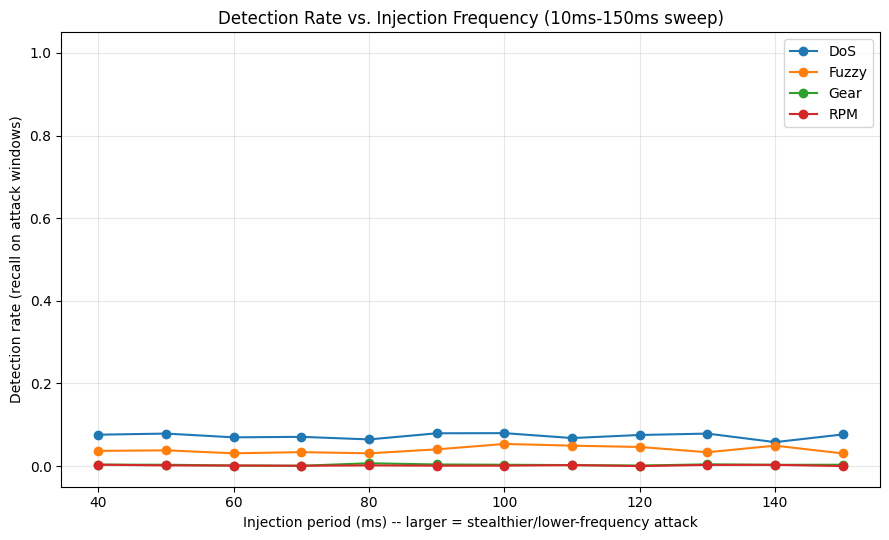


[INFO] Robustness boundary summary (detection rate at each tested period):
  DoS   : 40ms:0.08, 50ms:0.08, 60ms:0.07, 70ms:0.07, 80ms:0.06, 90ms:0.08, 100ms:0.08, 110ms:0.07, 120ms:0.08, 130ms:0.08, 140ms:0.06, 150ms:0.08
  Fuzzy : 40ms:0.04, 50ms:0.04, 60ms:0.03, 70ms:0.03, 80ms:0.03, 90ms:0.04, 100ms:0.05, 110ms:0.05, 120ms:0.05, 130ms:0.03, 140ms:0.05, 150ms:0.03
  Gear  : 40ms:0.00, 50ms:0.00, 60ms:0.00, 70ms:0.00, 80ms:0.01, 90ms:0.00, 100ms:0.00, 110ms:0.00, 120ms:0.00, 130ms:0.00, 140ms:0.00, 150ms:0.00
  RPM   : 40ms:0.00, 50ms:0.00, 60ms:0.00, 70ms:0.00, 80ms:0.00, 90ms:0.00, 100ms:0.00, 110ms:0.00, 120ms:0.00, 130ms:0.00, 140ms:0.00, 150ms:0.00


In [12]:
print("[INFO] Running low-frequency injection robustness sweep (10ms-150ms)...")

TARGET_PERIODS_MS = list(range(10, 151, 10))  # 10, 20, ..., 150 ms
SWEEP_WINDOW = 128
SWEEP_STRIDE = 16
# THRESHOLD FIX: this sweep tests detection of SPARSE, stealthy injections
# (one attack frame every 10-150ms), not dense training-style attacks. Reusing
# the training threshold (0.08, i.e. >=~10/128 attack frames) meant every
# tested period produced windows with attack-frame density well BELOW 0.08
# (e.g. a 10ms period on a ~0.3ms-interval bus yields only ~3-4 injected
# frames per 128-frame window, ~3% density) -- so every window was labelled
# "Normal" by ground truth and the sweep always found zero usable points.
# The ground truth for THIS analysis should be "does the window contain at
# least one injected attack frame", not "does it look like a dense attack".
SWEEP_THRESHOLD = 1.0 / SWEEP_WINDOW  # i.e. >=1 injected frame per window counts as attack


def load_frames_for_sweep(path):
    """Reloads one attack CSV and returns (normal_ids, normal_timestamps, attack_ids)."""
    df = pd.read_csv(path, names=CSV_COLUMNS, on_bad_lines="skip", low_memory=False)
    df["CAN_ID"] = df["CAN_ID"].astype(str).str.strip()
    df["Timestamp"] = pd.to_numeric(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"]).reset_index(drop=True)

    is_attack = df["Flag"].astype(str).str.strip().str.upper() != "R"
    normal_df = df[~is_attack]
    attack_df = df[is_attack]

    # Map CAN_IDs through the SAME global factorisation used for training so
    # the model sees IDs in the vocabulary it was actually trained on.
    def factorise(series):
        out = np.empty(len(series), dtype=np.int64)
        for i, cid in enumerate(series.values):
            out[i] = CAN_ID_MAP.get(cid, -1)
        return out

    normal_ids = factorise(normal_df["CAN_ID"])
    normal_ts = normal_df["Timestamp"].values
    attack_ids = factorise(attack_df["CAN_ID"])
    return normal_ids, normal_ts, attack_ids


def build_stream_at_period(normal_ids, normal_ts, attack_ids, target_period_ms, rng):
    """Injects attack_ids into the normal background at a fixed periodic spacing
    corresponding to target_period_ms, returning (id_stream, is_attack_mask)."""
    if len(normal_ts) < 2 or len(attack_ids) == 0:
        return None, None

    avg_frame_interval_ms = float(np.median(np.diff(normal_ts))) * 1000.0
    avg_frame_interval_ms = max(avg_frame_interval_ms, 1e-3)
    stride_frames = max(1, int(round(target_period_ms / avg_frame_interval_ms)))

    id_stream = normal_ids.copy()
    is_attack_mask = np.zeros(len(id_stream), dtype=bool)

    inject_positions = np.arange(0, len(id_stream), stride_frames)
    for pos in inject_positions:
        id_stream[pos] = attack_ids[rng.integers(0, len(attack_ids))]
        is_attack_mask[pos] = True

    return id_stream, is_attack_mask


def windows_from_stream(id_stream, is_attack_mask, window_size, stride, threshold):
    X_list, y_list = [], []
    for i in range(0, len(id_stream) - window_size, stride):
        seq = id_stream[i:i + window_size]
        frac = is_attack_mask[i:i + window_size].mean()
        label = 1 if frac >= threshold else 0  # binary: attack-window vs normal-window
        X_list.append(seq)
        y_list.append(label)
    if not X_list:
        return None, None
    return np.array(X_list), np.array(y_list)


rng_sweep = np.random.default_rng(SEED)
sweep_results = {name: {"period_ms": [], "accuracy": [], "detection_rate": [], "fpr": []}
                  for _, (name, _) in ATTACK_FILES.items()}

model.eval()
for attack_label, (name, path) in ATTACK_FILES.items():
    if not os.path.exists(path):
        print(f"[WARN] Skipping {name}: file not found at {path}")
        continue

    normal_ids, normal_ts, attack_ids = load_frames_for_sweep(path)

    for period_ms in TARGET_PERIODS_MS:
        id_stream, is_attack_mask = build_stream_at_period(
            normal_ids, normal_ts, attack_ids, period_ms, rng_sweep
        )
        if id_stream is None:
            continue

        X_sweep, y_sweep_binary = windows_from_stream(
            id_stream, is_attack_mask, SWEEP_WINDOW, SWEEP_STRIDE, SWEEP_THRESHOLD
        )
        if X_sweep is None or len(np.unique(y_sweep_binary)) < 2:
            continue  # need both classes present to score detection rate / FPR at this period

        # MEMORY/CRASH FIX: with the corrected threshold, most periods now
        # produce hundreds of thousands of windows per file (HCRL CSVs are
        # multi-million-row logs). Building a full (N, 128, 128) recurrence
        # plot tensor and running one unbatched forward pass over ALL of them
        # exhausts Colab's RAM and crashes the runtime. Instead: (1) take a
        # reproducible stratified random subsample capped at
        # MAX_SWEEP_WINDOWS_PER_PERIOD, keeping the attack/normal ratio close
        # to the full population, and (2) run inference in batches via
        # DataLoader instead of one giant tensor.
        MAX_SWEEP_WINDOWS_PER_PERIOD = 3000
        SWEEP_BATCH_SIZE = 256

        if len(X_sweep) > MAX_SWEEP_WINDOWS_PER_PERIOD:
            attack_idx = np.where(y_sweep_binary == 1)[0]
            normal_idx = np.where(y_sweep_binary == 0)[0]
            # keep the observed class ratio, minimum 1 sample per class present
            frac_attack = len(attack_idx) / len(y_sweep_binary)
            n_attack = max(1, int(round(MAX_SWEEP_WINDOWS_PER_PERIOD * frac_attack)))
            n_normal = max(1, MAX_SWEEP_WINDOWS_PER_PERIOD - n_attack)
            sub_attack = rng_sweep.choice(attack_idx, size=min(n_attack, len(attack_idx)), replace=False)
            sub_normal = rng_sweep.choice(normal_idx, size=min(n_normal, len(normal_idx)), replace=False)
            sample_idx = np.concatenate([sub_attack, sub_normal])
            rng_sweep.shuffle(sample_idx)
            X_sweep = X_sweep[sample_idx]
            y_sweep_binary = y_sweep_binary[sample_idx]

        preds_chunks = []
        for start in range(0, len(X_sweep), SWEEP_BATCH_SIZE):
            batch = X_sweep[start:start + SWEEP_BATCH_SIZE]
            batch_rp = np.expand_dims(generate_categorical_rp(batch), axis=1)
            with torch.no_grad():
                logits = model(torch.tensor(batch_rp, dtype=torch.float32).to(device))
                preds_chunks.append(torch.argmax(logits, dim=1).cpu().numpy())
        preds_multiclass = np.concatenate(preds_chunks)

        # Collapse multi-class prediction to binary (Normal=0 vs Any-Attack=1) so it
        # can be compared against the binary "was this window attack-injected" ground
        # truth the frequency sweep is defined over.
        preds_binary = (preds_multiclass != 0).astype(int)

        acc = (preds_binary == y_sweep_binary).mean()
        attack_mask_gt = y_sweep_binary == 1
        normal_mask_gt = y_sweep_binary == 0
        detection_rate = preds_binary[attack_mask_gt].mean() if attack_mask_gt.any() else float("nan")
        fpr = preds_binary[normal_mask_gt].mean() if normal_mask_gt.any() else float("nan")

        sweep_results[name]["period_ms"].append(period_ms)
        sweep_results[name]["accuracy"].append(acc)
        sweep_results[name]["detection_rate"].append(detection_rate)
        sweep_results[name]["fpr"].append(fpr)

    print(f"[INFO] Completed sweep for {name}: "
          f"{len(sweep_results[name]['period_ms'])} usable frequency points")

# --- Plot: the "Robustness Boundary Matrix" the proposal promised ---
fig, ax = plt.subplots(figsize=(9, 5.5))
for name, res in sweep_results.items():
    if res["period_ms"]:
        ax.plot(res["period_ms"], res["detection_rate"], marker="o", label=name)

ax.set_xlabel("Injection period (ms) -- larger = stealthier/lower-frequency attack")
ax.set_ylabel("Detection rate (recall on attack windows)")
ax.set_title("Detection Rate vs. Injection Frequency (10ms-150ms sweep)")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("\n[INFO] Robustness boundary summary (detection rate at each tested period):")
for name, res in sweep_results.items():
    if res["period_ms"]:
        summary = ", ".join(f"{p}ms:{d:.2f}" for p, d in zip(res["period_ms"], res["detection_rate"]))
        print(f"  {name:6s}: {summary}")


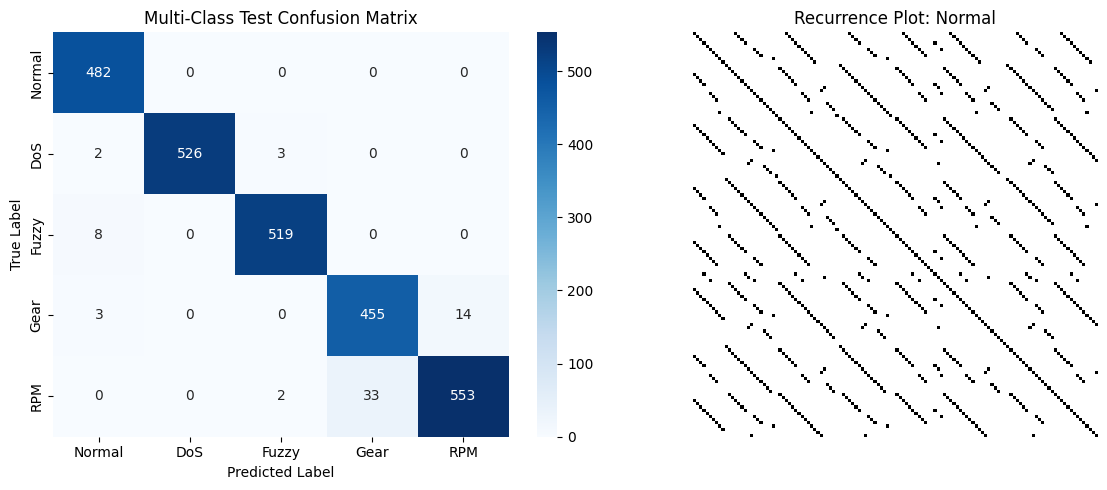

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=present_names,
    yticklabels=present_names
)
axes[0].set_title("Multi-Class Test Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Example recurrence plot from each present class (first occurrence)
example_idx = {c: int(np.where(y_raw == c)[0][0]) for c in sorted(set(y_raw))}
first_cls = sorted(example_idx.keys())[0]
axes[1].imshow(X_rp[example_idx[first_cls], 0], cmap='binary')
axes[1].set_title(f"Recurrence Plot: {CLASS_NAMES[first_cls]}")
axes[1].axis('off')

plt.tight_layout()
plt.show()


## STEP 6: Save checkpoint — now includes NUM_CLASSES, CLASS_NAMES, and the
persisted CAN_ID_MAP so inference can reuse the exact training-time
factorisation instead of re-deriving indices (fixes Section 5.4).

In [14]:
MODEL_SAVE_PATH = r"C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\lightweight_can_cnn_multiclass_new1.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'window_size': 128,
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'can_id_map': CAN_ID_MAP,     # persisted factorisation: CAN_ID string -> index
}, MODEL_SAVE_PATH)

print(f"\n[INFO] Multi-class model checkpoint saved to '{MODEL_SAVE_PATH}'")
print(f"[INFO] Persisted CAN_ID_MAP contains {len(CAN_ID_MAP)} unique arbitration IDs.")



[INFO] Multi-class model checkpoint saved to 'C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\lightweight_can_cnn_multiclass_new1.pth'
[INFO] Persisted CAN_ID_MAP contains 2048 unique arbitration IDs.


## STEP 7: Inference pipeline on unseen raw CAN streams (fixed preprocessing)

`predict_raw_can_list` looks up each CAN_ID string in the **persisted**
`can_id_map` from the checkpoint. IDs seen during training map to their exact
training-time index. IDs never seen during training all collapse onto a single
shared out-of-vocabulary label (`-1`), matching the proposal's Section 4.3
specification exactly, rather than each unseen ID getting its own distinct
placeholder index.


In [15]:
def load_trained_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)
    window_size = checkpoint.get('window_size', 128)
    num_classes = checkpoint.get('num_classes', 2)
    class_names = checkpoint.get('class_names', ['Normal', 'Attack'])
    can_id_map = checkpoint.get('can_id_map', {})

    loaded_model = LightweightCANCNN(window_size=window_size, num_classes=num_classes)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()

    print(f"[INFO] Model loaded successfully from '{model_path}' "
          f"({num_classes}-class: {class_names})")
    return loaded_model, window_size, num_classes, class_names, can_id_map


loaded_model, WINDOW_SIZE, NUM_CLASSES, CLASS_NAMES, CAN_ID_MAP = load_trained_model(
    MODEL_SAVE_PATH, device
)


def predict_raw_can_list(can_id_list, model, device, window_size, can_id_map, class_names):
    """
    Transforms raw CAN ID streams into 2D Categorical Recurrence Plots using
    the PERSISTED training-time id map, then generates threat predictions.
    Matches the proposal's Section 4.3 out-of-vocabulary handling exactly:
    ALL unseen/unknown IDs collapse onto a single shared label (-1), rather
    than each getting its own distinct placeholder index.
    """
    print(f"\n[INFO] Processing unseen stream of {len(can_id_list)} CAN IDs...")

    # Proposal Section 4.3: "Any unseen or anomalous identifiers ... are
    # automatically mapped to a dedicated out-of-vocabulary class label (-1)".
    # A single shared label for every unseen ID, not one placeholder per ID.
    OOV_LABEL = -1

    clean_ids = []
    for item in can_id_list:
        key = str(item).strip().upper() if isinstance(item, str) else item
        clean_ids.append(can_id_map.get(key, OOV_LABEL))

    can_ids_array = np.array(clean_ids)

    sequences = []
    for i in range(0, len(can_ids_array) - window_size + 1, window_size):
        sequences.append(can_ids_array[i:i + window_size])

    if len(sequences) == 0:
        raise ValueError(
            f"Input stream length ({len(can_id_list)}) is smaller than required window size ({window_size})!"
        )

    X_new_raw = np.array(sequences)
    X_new_rp = (X_new_raw[:, :, None] == X_new_raw[:, None, :]).astype(np.float32)
    X_new_tensor = torch.tensor(X_new_rp, dtype=torch.float32).unsqueeze(1).to(device)

    with torch.no_grad():
        logits = model(X_new_tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence_scores, predictions = torch.max(probabilities, dim=1)

    pred_np = predictions.cpu().numpy()
    results_df = pd.DataFrame({
        'Window_Index': np.arange(len(pred_np)),
        'Prediction_Class': pred_np,
        'Status': [class_names[p] for p in pred_np],
        'Confidence': confidence_scores.cpu().numpy()
    })

    return results_df


[INFO] Model loaded successfully from 'C:\Users\cherylin.LAPTOP-OASN0363\Desktop\CAN DETECTION\lightweight_can_cnn_multiclass_new1.pth' (5-class: ['Normal', 'DoS', 'Fuzzy', 'Gear', 'RPM'])


## STEP 8: Test inference on unseen streams — one per class where feasible

In [16]:
# Sample 1: Normal periodic CAN Bus traffic
unseen_normal_stream = [
    '00C4', '018F', '0280', '0316', '00C4', '018F', '0280', '0316',
    '00C4', '018F', '0280', '0316', '00C4', '018F', '0280', '0316'
] * 8

# Sample 2: High-entropy fuzzing-style stream (pseudo-random IDs)
unseen_fuzzing_stream = [f"{random.randint(0, 2047):04X}" for _ in range(128)]

# Sample 3: DoS-style dominant-ID flood (0x0000 repeated)
unseen_dos_stream = ['0000'] * 128

test_streams = {
    "Normal (periodic)": unseen_normal_stream,
    "Fuzzing (high-entropy)": unseen_fuzzing_stream,
    "DoS (dominant-ID flood)": unseen_dos_stream,
}

for label, stream in test_streams.items():
    print(f"\n=== EVALUATING: {label} ===")
    try:
        results = predict_raw_can_list(
            can_id_list=stream,
            model=loaded_model,
            device=device,
            window_size=WINDOW_SIZE,
            can_id_map=CAN_ID_MAP,
            class_names=CLASS_NAMES,
        )
        print(results.to_string(index=False))
    except Exception as e:
        print(f"[ERROR] Could not complete prediction for '{label}': {e}")



=== EVALUATING: Normal (periodic) ===

[INFO] Processing unseen stream of 128 CAN IDs...
 Window_Index  Prediction_Class Status  Confidence
            0                 1    DoS    0.702162

=== EVALUATING: Fuzzing (high-entropy) ===

[INFO] Processing unseen stream of 128 CAN IDs...
 Window_Index  Prediction_Class Status  Confidence
            0                 1    DoS    0.882511

=== EVALUATING: DoS (dominant-ID flood) ===

[INFO] Processing unseen stream of 128 CAN IDs...
 Window_Index  Prediction_Class Status  Confidence
            0                 1    DoS    0.996199
